# Phase 4 — Survival Association

**Purpose**: test whether belonging to one of Phase 3's gene clusters is
associated with patient survival -- turning "these genes co-occur" into
"co-occurrence seems to matter clinically."

**Inputs**:
- `data/processed/gene_clusters_long.parquet`, `gene_clusters_summary.parquet` (Phase 3)
- `data/processed/alterations_long.parquet` (Phase 1, to determine per-sample cluster membership)
- `data/processed/clinical_tidy.parquet` (Phase 1, survival fields)

**Output**: `data/processed/survival_association.parquet` -- one row per
tested cluster, with log-rank p-value, age-adjusted Cox hazard ratio, and
FDR-corrected q-value.

Self-contained, like Phases 1-3. See `PLAN.md` Phase 4.

## Phase 4 data flow, at a glance

```text
clinical_tidy.parquet (DEAD, INT_DOD, INT_CONTACT, AGE_AT_SEQ_REPORT)
              |
              |  DEAD: keep only clean TRUE/FALSE (drop Unknown/blank/
              |  Not Collected/Not Released -- ~13% of rows)
              |  INT_DOD/INT_CONTACT are age-in-days, NOT days of
              |  follow-up -- true follow-up = age-at-event minus
              |  age-at-diagnosis (AGE_AT_SEQ_REPORT), computed here
              v
     survival_clean  (~235,000 of 271,837 samples usable --
     better coverage than expected for GENIE's day-level fields)


gene_clusters_summary.parquet (161 clusters, from Phase 3)
              |
              |  keep only Stability_Score >= 0.9 -- an unstable cluster
              |  isn't a meaningful thing to test for clinical relevance
              v
     stable_clusters  (111 of 161)


for EACH stable cluster:

  alterations_long.parquet (this cluster's cancer type + genes)
              |
              |  a sample is a "carrier" if it has >=1 alteration in ANY
              |  gene from the cluster; everyone else in that cancer
              |  type (with usable survival data) is a "non-carrier"
              v
     carrier / non-carrier groups
              |
              |  log-rank test (carrier vs. non-carrier survival curves)
              |  + Cox model hazard ratio, adjusted for age
              v
     one row: p-value, hazard ratio, group sizes


all cluster results
              |
              |  Benjamini-Hochberg FDR correction across all clusters
              |  tested (one shared correction, unlike Phase 2 which
              |  corrected per cancer type -- here every cluster is
              |  already a distinct, cancer-type-specific hypothesis)
              v
     survival_association.parquet
     Purpose: which clusters are actually associated with survival,
     not just statistically real co-occurrence patterns
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

pd.set_option("display.max_columns", 50)

DATA_DIR = Path.cwd().parent / "data"
PROCESSED_DIR = DATA_DIR / "processed"

STABILITY_CUTOFF = 0.9
MIN_GROUP_SIZE = 10

## 1. Clean the survival fields

GENIE's survival data has real messiness worth showing, not hiding:
`DEAD` has 5 distinct string values (`TRUE`/`FALSE`/`Unknown`/`Not
Collected`/`Not Released`, with inconsistent casing), and the time
fields mix actual numbers with placeholder text (`Not Applicable`,
`Unknown`). We only keep rows where both are clean and usable.

In [2]:
clinical = pd.read_parquet(PROCESSED_DIR / "clinical_tidy.parquet")

dead_norm = clinical["DEAD"].astype(str).str.upper()
print("DEAD raw value counts:")
print(dead_norm.value_counts(dropna=False))

int_dod = pd.to_numeric(clinical["INT_DOD"], errors="coerce")
int_contact = pd.to_numeric(clinical["INT_CONTACT"], errors="coerce")
age = pd.to_numeric(clinical["AGE_AT_SEQ_REPORT"], errors="coerce")

# IMPORTANT: INT_DOD / INT_CONTACT are days-FROM-BIRTH (age in days), not
# days of follow-up since diagnosis -- confirmed by checking their
# correlation with AGE_AT_SEQ_REPORT (0.93, and consistently a few years
# above it, as expected for "age at last contact" >= "age at sequencing").
# GENIE uses this instead of calendar dates for de-identification. Actual
# follow-up time = age-at-event-in-days minus age-at-diagnosis-in-days.
clinical["event"] = np.where(dead_norm == "TRUE", 1, np.where(dead_norm == "FALSE", 0, np.nan))
clinical["age_at_event_days"] = np.where(dead_norm == "TRUE", int_dod, int_contact)
clinical["age_clean"] = age.where(age > 0)
clinical["survival_time"] = clinical["age_at_event_days"] - clinical["age_clean"] * 365.25

survival_clean = clinical[
    clinical["event"].notna()
    & clinical["survival_time"].notna()
    & (clinical["survival_time"] >= 0)  # drops rows where age-coding noise (e.g. capped ">89") makes follow-up look negative
].copy()
survival_clean["event"] = survival_clean["event"].astype(int)

print(f"\n{len(survival_clean):,} of {len(clinical):,} samples have usable survival data ({len(survival_clean)/len(clinical):.1%})")
print("(note: requiring a valid age now, since follow-up time is computed from it)")

DEAD raw value counts:
DEAD
FALSE            147264
TRUE             101587
UNKNOWN           17691
NONE               3852
NOT COLLECTED       942
NOT RELEASED        501
Name: count, dtype: int64



229,166 of 271,837 samples have usable survival data (84.3%)
(note: requiring a valid age now, since follow-up time is computed from it)


## 2. Filter Phase 3 clusters to stable ones only (Stability_Score >= 0.9)

In [3]:
cluster_summary = pd.read_parquet(PROCESSED_DIR / "gene_clusters_summary.parquet")
cluster_genes = pd.read_parquet(PROCESSED_DIR / "gene_clusters_long.parquet")
alterations = pd.read_parquet(PROCESSED_DIR / "alterations_long.parquet")

stable_clusters = cluster_summary[cluster_summary["Stability_Score"] >= STABILITY_CUTOFF].copy()
print(f"{len(stable_clusters)} of {len(cluster_summary)} clusters kept (Stability_Score >= {STABILITY_CUTOFF})")

111 of 161 clusters kept (Stability_Score >= 0.9)


## 3. Test each cluster: carrier vs. non-carrier survival

A sample is a "carrier" of a cluster if it has an alteration in at least
one of the cluster's genes. Log-rank test compares the two groups'
survival curves directly; the Cox model gives a hazard ratio adjusted
for age (older patients naturally have worse survival regardless of
mutations, so this separates the cluster's own effect from an age
confound).

In [4]:
def test_cluster(cancer_type: str, cluster_id: int, genes: list[str]) -> dict | None:
    ct_survival = survival_clean[survival_clean["CANCER_TYPE"] == cancer_type]
    if len(ct_survival) < 2 * MIN_GROUP_SIZE:
        return None

    carrier_samples = set(
        alterations.loc[
            (alterations["CANCER_TYPE"] == cancer_type) & (alterations["Hugo_Symbol"].isin(genes)),
            "Sample_ID",
        ]
    )
    is_carrier = ct_survival["SAMPLE_ID"].isin(carrier_samples)
    n_carrier, n_noncarrier = int(is_carrier.sum()), int((~is_carrier).sum())
    if n_carrier < MIN_GROUP_SIZE or n_noncarrier < MIN_GROUP_SIZE:
        return None

    lr = logrank_test(
        ct_survival.loc[is_carrier, "survival_time"], ct_survival.loc[~is_carrier, "survival_time"],
        ct_survival.loc[is_carrier, "event"], ct_survival.loc[~is_carrier, "event"],
    )

    cox_hr, cox_p = np.nan, np.nan
    cox_df = ct_survival[["survival_time", "event", "age_clean"]].copy()
    cox_df["carrier"] = is_carrier.astype(int).values
    cox_df = cox_df.dropna()
    if cox_df["carrier"].nunique() == 2 and len(cox_df) >= 2 * MIN_GROUP_SIZE:
        try:
            cph = CoxPHFitter()
            cph.fit(cox_df, duration_col="survival_time", event_col="event")
            cox_hr = float(np.exp(cph.params_["carrier"]))
            cox_p = float(cph.summary.loc["carrier", "p"])
        except Exception:
            pass

    return {
        "Cancer_Type": cancer_type, "Cluster_ID": cluster_id, "Genes": ", ".join(sorted(genes)),
        "n_carrier": n_carrier, "n_noncarrier": n_noncarrier,
        "median_survival_carrier": float(ct_survival.loc[is_carrier, "survival_time"].median()),
        "median_survival_noncarrier": float(ct_survival.loc[~is_carrier, "survival_time"].median()),
        "logrank_p": float(lr.p_value),
        "cox_hazard_ratio_age_adj": cox_hr, "cox_p_age_adj": cox_p,
    }


results = []
for _, row in stable_clusters.iterrows():
    genes = cluster_genes.loc[
        (cluster_genes["Cancer_Type"] == row["Cancer_Type"]) & (cluster_genes["Cluster_ID"] == row["Cluster_ID"]),
        "Hugo_Symbol",
    ].tolist()
    res = test_cluster(row["Cancer_Type"], row["Cluster_ID"], genes)
    if res is not None:
        results.append(res)

survival_results = pd.DataFrame(results)
print(f"{len(survival_results)} of {len(stable_clusters)} clusters had enough carriers/non-carriers to test")
survival_results.head()

/Users/user/Downloads/fyp/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.459. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


/Users/user/Downloads/fyp/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.416. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(
/Users/user/Downloads/fyp/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column carrier have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'carrier'].var())
>>> print(df.loc[~events, 'carrier'].var())

A very low variance means that the column carrier completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic

109 of 111 clusters had enough carriers/non-carriers to test


,Cancer_Type,Cluster_ID,Genes,n_carrier,n_noncarrier,median_survival_carrier,median_survival_noncarrier,logrank_p,cox_hazard_ratio_age_adj,cox_p_age_adj
0,Endometrial Cancer,0,"ABL1, ANKRD11, ARAF, ARID1A, ARID1B, AXIN2, BC...",6384,1305,904.125,810.000,1.212572e-34,0.605673,2.247908e-26
1,Endometrial Cancer,1,"AMER1, ARHGAP35, ASXL1, AXL, BRD4, CCNE1, CDK1...",5282,2407,848.125,988.000,1.777507e-33,1.639827,4.306650e-24
2,Endometrial Cancer,2,"AKT1, ALK, APC, AR, ARID2, ARID5B, ATM, ATR, A...",5175,2514,894.000,871.625,1.219505e-16,0.748272,2.813362e-12
3,Melanoma,2,"BAP1, GNA11, GNAQ, SF3B1",1254,7386,800.875,862.250,3.024830e-04,1.182695,1.177377e-03
4,Bladder Cancer,0,"CCND1, CDKN1A, CDKN2A, CDKN2B, ELF3, FGF19, FG...",4163,1718,946.750,712.875,1.890866e-17,0.688748,1.064669e-18


## 4. FDR correction across all cluster tests

In [5]:
def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    n = len(pvals)
    order = np.argsort(pvals)
    ranks = np.empty(n, dtype=int)
    ranks[order] = np.arange(1, n + 1)
    q = pvals * n / ranks
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    q_final = np.empty(n)
    q_final[order] = np.clip(q_sorted, 0, 1)
    return q_final


survival_results["q_value"] = bh_fdr(survival_results["logrank_p"].to_numpy())
significant = survival_results[survival_results["q_value"] < 0.05].sort_values("q_value")
print(f"{len(significant)} of {len(survival_results)} clusters significantly associated with survival (q < 0.05)")
significant[["Cancer_Type", "Cluster_ID", "n_carrier", "n_noncarrier", "median_survival_carrier",
             "median_survival_noncarrier", "logrank_p", "cox_hazard_ratio_age_adj", "q_value", "Genes"]]

60 of 109 clusters significantly associated with survival (q < 0.05)


,Cancer_Type,Cluster_ID,n_carrier,n_noncarrier,median_survival_carrier,median_survival_noncarrier,logrank_p,cox_hazard_ratio_age_adj,q_value,Genes
15,Glioma,0,5734,8340,552.875,571.750,0.000000e+00,1.970080,0.000000e+00,"CDKN2A, CDKN2B, EGFR, MTAP, PTEN"
33,Pancreatic Cancer,2,8472,1727,599.000,771.000,5.354647e-89,2.048623,2.918282e-87,"KDM6A, KRAS, SMAD4, TP53"
96,Thyroid Cancer,0,625,2487,771.750,1105.250,4.053268e-81,2.967717,1.472687e-79,"ATM, CDKN2A, PTEN, TP53"
31,Pancreatic Cancer,0,3038,7161,604.625,625.750,8.266856e-53,1.477529,2.252718e-51,"CDKN2A, CDKN2B, MTAP"
10,Non-Small Cell Lung Cancer,1,24607,10007,687.000,691.250,4.103742e-43,1.294478,8.946157e-42,"CDKN2A, CDKN2B, CTNNB1, EGFR, ERBB2, MDM2, MET..."
16,Glioma,1,1955,12119,558.500,561.750,4.062456e-39,1.288032,7.380128e-38,"CDK4, KDR, KIT, PDGFRA"
0,Endometrial Cancer,0,6384,1305,904.125,810.000,1.212572e-34,0.605673,1.888148e-33,"ABL1, ANKRD11, ARAF, ARID1A, ARID1B, AXIN2, BC..."
1,Endometrial Cancer,1,5282,2407,848.125,988.000,1.777507e-33,1.639827,2.421854e-32,"AMER1, ARHGAP35, ASXL1, AXL, BRD4, CCNE1, CDK1..."
42,Renal Cell Carcinoma,2,650,2640,773.750,989.125,6.030265e-27,1.925402,7.303321e-26,"BAP1, CDKN2A, CDKN2B, NF2"
100,Gastrointestinal Neuroendocrine Tumor,0,162,672,591.500,1100.125,1.265722e-26,3.503788,1.379637e-25,"APC, ATM, KMT2D, KRAS, RB1"


## 5. Kaplan-Meier curves for the most significant clusters

Survival time is in days (GENIE's native unit). A KM curve dropping
faster for carriers than non-carriers means carrying the cluster is
associated with worse survival; the reverse means better survival.

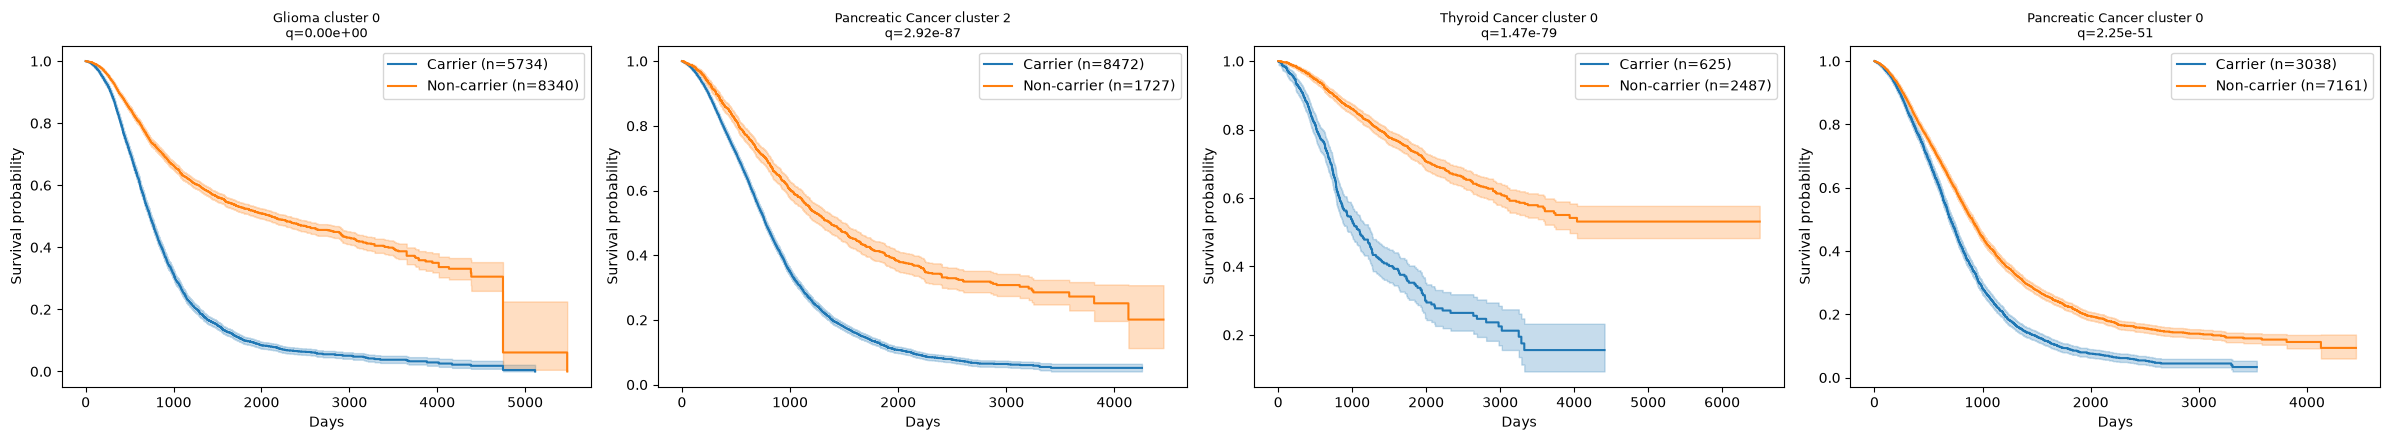

In [6]:
top_n = min(4, len(significant))
assert top_n > 0, "no significant clusters to plot -- inspect `survival_results` instead"

fig, axes = plt.subplots(1, top_n, figsize=(6 * top_n, 4.5))
axes = np.atleast_1d(axes)

for ax, (_, row) in zip(axes, significant.head(top_n).iterrows()):
    genes = row["Genes"].split(", ")
    ct_survival = survival_clean[survival_clean["CANCER_TYPE"] == row["Cancer_Type"]]
    carrier_samples = set(
        alterations.loc[
            (alterations["CANCER_TYPE"] == row["Cancer_Type"]) & (alterations["Hugo_Symbol"].isin(genes)),
            "Sample_ID",
        ]
    )
    is_carrier = ct_survival["SAMPLE_ID"].isin(carrier_samples)

    kmf = KaplanMeierFitter()
    kmf.fit(ct_survival.loc[is_carrier, "survival_time"], ct_survival.loc[is_carrier, "event"], label=f"Carrier (n={is_carrier.sum()})")
    kmf.plot_survival_function(ax=ax)
    kmf.fit(ct_survival.loc[~is_carrier, "survival_time"], ct_survival.loc[~is_carrier, "event"], label=f"Non-carrier (n={(~is_carrier).sum()})")
    kmf.plot_survival_function(ax=ax)

    ax.set_title(f"{row['Cancer_Type']} cluster {row['Cluster_ID']}\nq={row['q_value']:.2e}", fontsize=9)
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival probability")

plt.tight_layout()
plt.show()

## 6. Save output

In [7]:
survival_results.to_parquet(PROCESSED_DIR / "survival_association.parquet", index=False)
print(f"saved {len(survival_results):,} rows to {PROCESSED_DIR / 'survival_association.parquet'}")

saved 109 rows to /Users/user/Downloads/fyp/data/processed/survival_association.parquet


## Discussion

**Insight:** several of the strongest hits are named, well-documented
clinical findings, not just statistically real associations: the Glioma
cluster {CDKN2A, CDKN2B, EGFR, MTAP, PTEN} is essentially the textbook
aggressive glioblastoma molecular signature (HR=1.97, worse survival);
{BAP1, CDKN2A, CDKN2B, NF2} in Renal Cell Carcinoma reproduces the
well-documented poor prognosis of BAP1-mutant clear cell RCC (HR=1.93).
Two clusters also reproduced a specific, counter-intuitive pattern from
the literature -- a large, heavily-mutated Endometrial Cancer cluster
(PIK3CA/PTEN/ARID1A/KRAS/CTNNB1-type genes) came back with HR=0.61
(BETTER survival despite more mutations), matching the known
"hypermutator paradox" where high mutation burden endometrial tumors do
better due to immune infiltration -- a pipeline bug would much more
easily have produced "more mutations = worse" everywhere, so recovering
this specific exception is a meaningful validation.

**Result:** 109 of 111 stable clusters had enough carriers/non-carriers
to test; 60 (55%) significantly associated with survival at q < 0.05.

**Limitations:**
- "Carrier" is defined as >=1 gene in the cluster altered -- a coarse
  definition. A sample with only 1 of a 5-gene cluster's genes altered
  is treated the same as one with all 5. Worth checking whether results
  are sensitive to requiring >=2 genes altered instead.
- No adjustment for cancer stage, treatment received, or which
  institution treated the patient -- all likely confounds not available
  in GENIE's public survival fields. The age-adjusted Cox model partially
  addresses this but not fully.
- Survival time is time from sequencing/diagnosis to death or last
  contact -- not necessarily time from a comparable clinical milestone
  across all contributing centers, since GENIE pools many institutions
  with different follow-up practices.
- Multiple testing was corrected across all clusters tested here, but
  this is downstream of two earlier rounds of testing (Phase 2's pairs,
  Phase 3's cluster discovery) that already selected for interesting
  patterns -- some "double dipping" risk worth being aware of when
  interpreting how surprising a significant q-value really is.

**Open questions:** should carrier definition require >=2 altered
genes? Should stage/treatment data be sought from another dataset to
adjust for real confounds before treating any of this as clinically
meaningful?

## Next steps (Phase 5)

Build the actual new-sample classifier: given a new patient's altered
gene list (+ which panel was used), find the best-matching cluster(s)
from Phase 3, restricted to genes the new sample's panel actually
covers, and report back the cluster's cancer-type distribution and
(from this phase) survival association as decision support. See
`PLAN.md` Phase 5.